In [1]:
import mne
import os
import numpy as np
from os import walk
import copy
from matplotlib import pyplot as plt

In [2]:
experiment_num = 0
root = ('experiments/')
list_file_names = []
for path, dirs, files in os.walk(root):
    for file in files:
        if file.endswith(".bdf"):
             list_file_names.append(os.path.join(root, file))
print(len(list_file_names),'files')
files = []
path = 'experiments/'
participant_prefix = list_file_names[experiment_num][12:-4]
for (dirpath, dirnames, filenames) in walk(path):
    new_names = [dirpath+f for f in filenames if (participant_prefix in f)]
    files.extend(new_names)
    break
# 2, 4, 10 are the preferable experiments to work with

raw = mne.io.read_raw_bdf(files[0],preload=True)
raw.resample(sfreq=raw.info['sfreq']/8)
print(raw.info['meas_date'])
events = mne.find_events(raw, stim_channel=None,initial_event=False)
excluded = ['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
raw.info['bads'] = excluded
raw.pick_types(meg=False, eeg=True, eog=False, exclude='bads')
data = raw._data
sfreq = raw.info['sfreq']
ch_names = raw.info['ch_names']

21 files
Extracting EDF parameters from C:\Users\serha\NonDrive\EEG_work\trials\experiments\aq values deu neg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 831487  =      0.000 ...   406.000 secs...
Trigger channel Status has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
245 events found on stim channel Status
Event IDs: [  1   2   4   8   9  10  16  25  32  64  73 128]
Trigger channel Status has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
237 events found on stim channel Status
Event IDs: [  1   2   4   8   9  10  16  32  64 128]
2002-01-09 06:58:59+00:00
Trigger channel Status has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Removing orphaned offset at t

C:\Users\serha\AppData\Local\Temp\ipykernel_9960\703488210.py:19: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw.resample(sfreq=raw.info['sfreq']/8)


In [3]:
# with experiment labels
indices = []
marking_list = [item[2] for item in events]
print('complete experiment sequence \n',marking_list)
print('')
patterns = [i+[item] for item in [16,32,64,128] for i in [[item]+[1,2,4,8] for item in [9,10]]]
pat_len = len(patterns[0])
epoch_list = []
counter = 0
for i in range(1,len(marking_list)-1):
    if marking_list[i] in [16,32,64,128]:
        if marking_list[i-1] in [16,32,64,128]:
            epoch_list = epoch_list[:-1]
            indices = indices[:-1]
        for item in range(i,i-pat_len,-1):
            if set([1,2,4,8]) <= set(marking_list[item:i]):
                if marking_list[item-1] in [9,10]:
                    epoch_list.append(marking_list[item-1:i+1])
                    indices.append([item-1,i])
                    break
                if marking_list[item-1] not in [9,10]:
                    epoch_list.append(marking_list[item:i+1])
                    indices.append([item,i])
                    break
    if counter < len(marking_list):
        counter+=1
    else:
        break
print('number of epochs: ', len(epoch_list))
print(epoch_list)

marked_time_points = [item[0] for item in events]
epochs_time_intervals = []
for item in indices:
    epochs_time_intervals.append([marked_time_points[item[0]],marked_time_points[item[1]]])

epoch_lengths = [i[1]-i[0] for i in epochs_time_intervals]
print('')
print('timings for first and last markings in epoch || length of epoch || markings')
for i in range(len(epoch_list)):
    print([epochs_time_intervals[i],epoch_lengths[i],epoch_list[i]])

epochs_events = []
for item in epoch_list:
    if item[0] == 9:
        epochs_events.append('C') # label for congruency
    if item[0] == 10:
        epochs_events.append('IC') # label for incongruency
    if item[0] not in [9,10]:
        epochs_events.append('N') # label for neutral?

print('')
print('number of congruent events:', epochs_events.count('C'))
print('number of incongruent events:', epochs_events.count('IC'))
print('number of neutral events:', epochs_events.count('N'))
print('average epoch length: ', sum(epoch_lengths) / len(epoch_lengths))
print('minimum epoch length: ', min(epoch_lengths))
print('maximum epoch length: ', max(epoch_lengths))

complete experiment sequence 
 [128, 1, 2, 4, 8, 64, 10, 1, 2, 4, 16, 8, 16, 10, 1, 2, 4, 8, 64, 1, 2, 4, 8, 128, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 16, 1, 2, 4, 8, 64, 10, 1, 2, 4, 8, 64, 9, 1, 2, 4, 8, 64, 9, 1, 2, 4, 8, 32, 10, 1, 2, 4, 8, 32, 9, 1, 2, 4, 8, 64, 10, 1, 2, 4, 8, 16, 1, 2, 4, 8, 16, 9, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 64, 9, 1, 2, 4, 16, 8, 16, 9, 1, 2, 4, 8, 128, 10, 1, 2, 4, 8, 32, 9, 1, 2, 4, 8, 64, 1, 2, 4, 8, 16, 1, 2, 4, 8, 16, 9, 1, 2, 4, 16, 8, 16, 1, 2, 4, 8, 64, 1, 2, 4, 8, 32, 1, 2, 4, 8, 64, 10, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 64, 1, 2, 4, 8, 64, 10, 1, 2, 4, 8, 32, 10, 1, 2, 4, 8, 64, 1, 2, 4, 8, 64, 1, 2, 4, 8, 16, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 16, 9, 1, 2, 4, 8, 32, 9, 1, 2, 4, 8, 32, 10, 1, 2, 4, 8, 128, 9, 1, 2, 4, 8, 128, 9, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 64, 128]

number of epochs:  41
[[1, 2, 4, 8, 64], [10, 1, 2, 4, 16, 8, 16], [10, 1, 2, 4, 8, 64], [1, 2, 4, 8, 128], [1, 2, 4, 8, 16], [10, 1, 2, 4, 8, 16], [1, 2, 4, 8, 64], [10, 1, 2, 4, 8, 64], [

In [4]:
# without experiment labels
indices = []
indices_code_2 = []
marking_list = [item[2] for item in events]
print('complete experiment sequence \n', marking_list)
print('')
patterns = [i+[item] for item in [16,32,64,128] for i in [[item]+[1,2,4,8] for item in [9,10]]]
pat_len = len(patterns[0])
epoch_list_noLabel = []
counter = 0
for i in range(1,len(marking_list)-1):
    if marking_list[i] in [16,32,64,128]:
        if marking_list[i-1] in [16,32,64,128]:
            epoch_list_noLabel = epoch_list_noLabel[:-1]
            indices = indices[:-1]
            indices_code_2 = indices_code_2[:-1]
        for item in range(i,i-pat_len,-1):
            if set([1,2,4,8]) <= set(marking_list[item:i]):
                #if marking_list[item-1] in [9,10]:
                #    epoch_list_noLabel.append(marking_list[item-1:i+1])
                #    indices.append([item-1,i])
                #    break
                #if marking_list[item-1] not in [9,10]:
                epoch_list_noLabel.append(marking_list[item:i+1])
                indices.append([item,i])
                indices_code_2.append([item+1,i])
                break
    if counter < len(marking_list):
        counter+=1
    else:
        break
print('number of epochs: ', len(epoch_list_noLabel))
print(epoch_list_noLabel)

marked_time_points = [item[0] for item in events]
epochs_time_intervals = []
for item in indices:
    epochs_time_intervals.append([marked_time_points[item[0]],marked_time_points[item[1]]])

epoch_lengths = [i[1]-i[0] for i in epochs_time_intervals]
print('')
print('timings for first and last markings in epoch || length of epoch || markings')
for i in range(len(epoch_list_noLabel)):
    print([epochs_time_intervals[i],epoch_lengths[i],epoch_list_noLabel[i]])
    
print('')
print('average epoch length: ', sum(epoch_lengths) / len(epoch_lengths))
print('minimum epoch length: ', min(epoch_lengths))
print('maximum epoch length: ', max(epoch_lengths))

complete experiment sequence 
 [128, 1, 2, 4, 8, 64, 10, 1, 2, 4, 16, 8, 16, 10, 1, 2, 4, 8, 64, 1, 2, 4, 8, 128, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 16, 1, 2, 4, 8, 64, 10, 1, 2, 4, 8, 64, 9, 1, 2, 4, 8, 64, 9, 1, 2, 4, 8, 32, 10, 1, 2, 4, 8, 32, 9, 1, 2, 4, 8, 64, 10, 1, 2, 4, 8, 16, 1, 2, 4, 8, 16, 9, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 64, 9, 1, 2, 4, 16, 8, 16, 9, 1, 2, 4, 8, 128, 10, 1, 2, 4, 8, 32, 9, 1, 2, 4, 8, 64, 1, 2, 4, 8, 16, 1, 2, 4, 8, 16, 9, 1, 2, 4, 16, 8, 16, 1, 2, 4, 8, 64, 1, 2, 4, 8, 32, 1, 2, 4, 8, 64, 10, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 64, 1, 2, 4, 8, 64, 10, 1, 2, 4, 8, 32, 10, 1, 2, 4, 8, 64, 1, 2, 4, 8, 64, 1, 2, 4, 8, 16, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 16, 9, 1, 2, 4, 8, 32, 9, 1, 2, 4, 8, 32, 10, 1, 2, 4, 8, 128, 9, 1, 2, 4, 8, 128, 9, 1, 2, 4, 8, 16, 10, 1, 2, 4, 8, 64, 128]

number of epochs:  41
[[1, 2, 4, 8, 64], [1, 2, 4, 16, 8, 16], [1, 2, 4, 8, 64], [1, 2, 4, 8, 128], [1, 2, 4, 8, 16], [1, 2, 4, 8, 16], [1, 2, 4, 8, 64], [1, 2, 4, 8, 64], [1, 2, 4, 8, 64],

In [5]:
# cropped epochs (shortened from starting point)
shortened_intervals = []
for i in range(len(epoch_list_noLabel)):
    if epoch_lengths[i] == min(epoch_lengths):
        shortened_intervals.append(epochs_time_intervals[i])
    if epoch_lengths[i] > min(epoch_lengths):
        shortened_intervals.append([epochs_time_intervals[i][0]+(epoch_lengths[i]-min(epoch_lengths)), epochs_time_intervals[i][1]])
#shortened_intervals

epochs_from_code_2_intervals = []
for item in indices_code_2:
    epochs_from_code_2_intervals.append([marked_time_points[item[0]],marked_time_points[item[1]]])

print('timings for cropped epochs || length of epoch || timings starting with code-2 || markings')
for i in range(len(epoch_list_noLabel)):
    if epochs_from_code_2_intervals[i][0]-shortened_intervals[i][0] < 0:
        print('WARNING: code-2 is not in the epoch!')
    print([shortened_intervals[i],shortened_intervals[i][1]-shortened_intervals[i][0],epochs_from_code_2_intervals[i],epoch_list_noLabel[i][1:]])

timings for cropped epochs || length of epoch || timings starting with code-2 || markings
[[30935, 32073], 1138, [31023, 32073], [2, 4, 8, 64]]
[[32656, 33794], 1138, [32651, 33794], [2, 4, 16, 8, 16]]
[[34112, 35250], 1138, [34411, 35250], [2, 4, 8, 64]]
[[35744, 36882], 1138, [35851, 36882], [2, 4, 8, 128]]
[[37118, 38256], 1138, [37534, 38256], [2, 4, 8, 16]]
[[38513, 39651], 1138, [38834, 39651], [2, 4, 8, 16]]
[[40186, 41324], 1138, [40215, 41324], [2, 4, 8, 64]]
[[42039, 43177], 1138, [41966, 43177], [2, 4, 8, 64]]
[[43561, 44699], 1138, [43832, 44699], [2, 4, 8, 64]]
[[45064, 46202], 1138, [45341, 46202], [2, 4, 8, 32]]
[[46770, 47908], 1138, [46832, 47908], [2, 4, 8, 32]]
[[48298, 49436], 1138, [48511, 49436], [2, 4, 8, 64]]
[[49639, 50777], 1138, [50003, 50777], [2, 4, 8, 16]]
[[51069, 52207], 1138, [51366, 52207], [2, 4, 8, 16]]
[[52508, 53646], 1138, [52900, 53646], [2, 4, 8, 16]]
[[54034, 55172], 1138, [54277, 55172], [2, 4, 8, 64]]
[[55453, 56591], 1138, [55789, 56591], [2

In [6]:
n_channels = data.shape[0]
n_times = shortened_intervals[0][1]-shortened_intervals[0][0]
data.shape

participant_data = np.ndarray((len(epoch_list),n_channels,n_times))
#participant_data = np.ndarray((len(epoch_list)))
#pd = [x for x in range(len(epoch_list))]

for i in range(len(epoch_list)):
    new_data = np.array([item[shortened_intervals[i][0]:shortened_intervals[i][1]] for item in data])
    if i == 0:
        print('n_channels, n_times: ' + str(new_data.shape))
    #new_data = new_data.astype(float)
    participant_data[i] = new_data

print('Number of epochs: ' + str(len(participant_data)))    

n_channels, n_times: (32, 1138)
Number of epochs: 41


In [7]:
unique_events = sorted(list(set(epochs_events)))
print(unique_events)
unique_events_num = [i for i in range(len(unique_events))]
epoch_events_num = np.ndarray((len(epochs_events),3),int)

for i in range(len(epochs_events)):
    for j in range(len(unique_events)):
        if epochs_events[i] == unique_events[j]:
            epoch_events_num[i,2] = unique_events_num[j]
            if i >0:
                epoch_events_num[i,1] = epoch_events_num[i-1,2]
            else:
                epoch_events_num[i,1] = unique_events_num[j]
        epoch_events_num[i,0] = i
        
event_id = {}
for i in range(len(unique_events)):
    #if unique_events[i] in [1,2,4,8,9,10,16,32,64,128]:
    event_id[unique_events[i]] = unique_events_num[i]
print(event_id)

['C', 'IC', 'N']
{'C': 0, 'IC': 1, 'N': 2}


In [8]:
epochs_info = mne.create_info(ch_names, sfreq, ch_types='eeg')
epochs = mne.EpochsArray(data=participant_data, info=epochs_info, events=epoch_events_num, event_id=event_id)
epochs.set_montage('biosemi32')
#epochs.drop_bad()

Not setting metadata
41 matching events found
No baseline correction applied
0 projection items activated


Number of events,41
Events,C: 12IC: 15N: 14
Time range,0.000 – 4.441 s
Baseline,off


In [9]:
%matplotlib inline

Applying baseline correction (mode: mean)


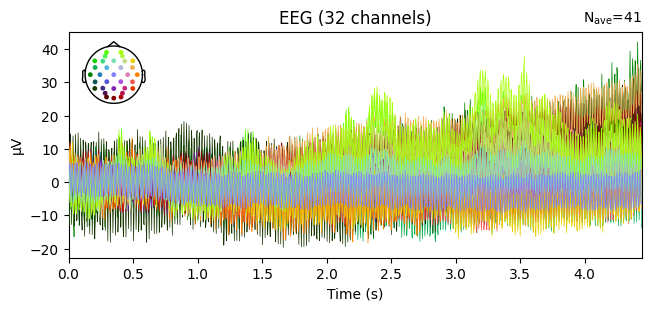

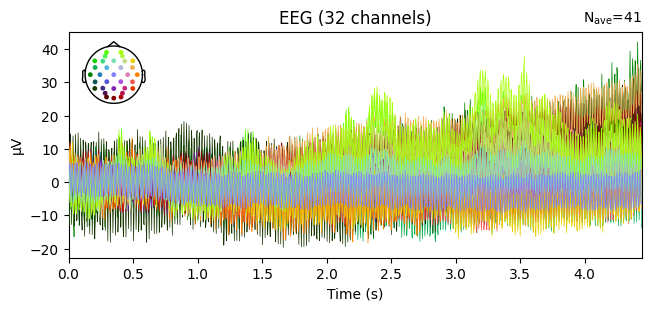

In [10]:
epochs_wo_bc = copy.deepcopy(epochs)
# baseline correction
inteval = (0, 1)
bc_epochs = epochs.apply_baseline(inteval)

# Plot of baseline-corrected evoked signal
bc_epochs.average().plot()

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.


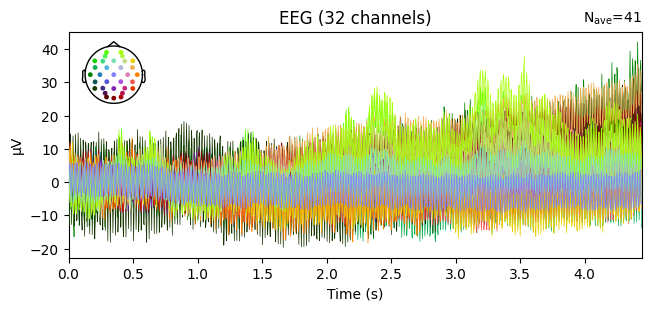

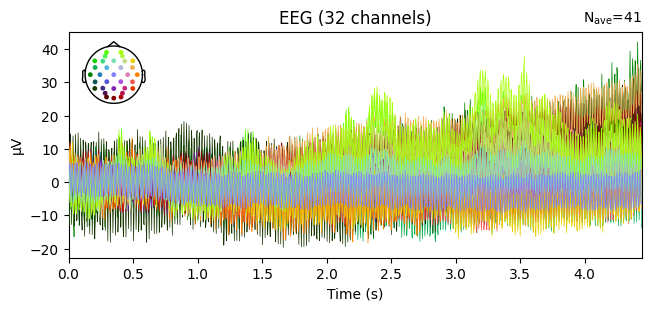

In [11]:
# create two copies of original epochs object for further comparison
#original_1 = copy.deepcopy(bc_epochs)
#original_2 = copy.deepcopy(bc_epochs)

# Re-reference by averaging
#re_ref_epochs = original_1.set_eeg_reference('average', projection=True)
re_ref_epochs = bc_epochs.set_eeg_reference('average', projection=True)

re_ref_epochs.average().plot()

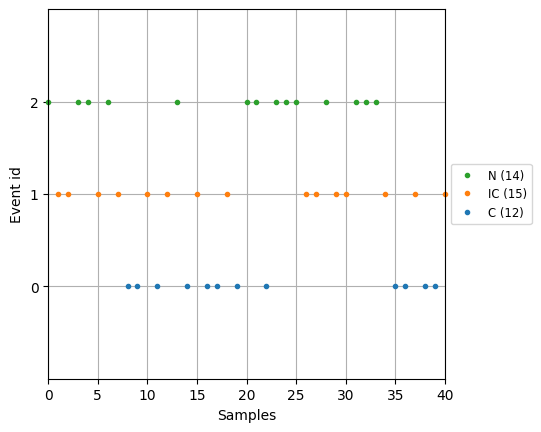

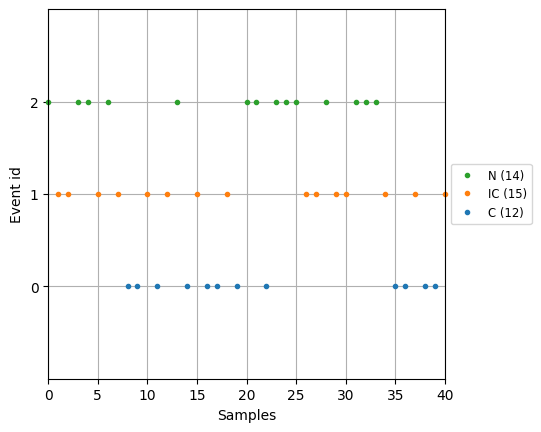

In [12]:
#plot events
mne.viz.plot_events(re_ref_epochs.events,event_id={'C': 0, 'IC': 1, 'N': 2})

Using matplotlib as 2D backend.


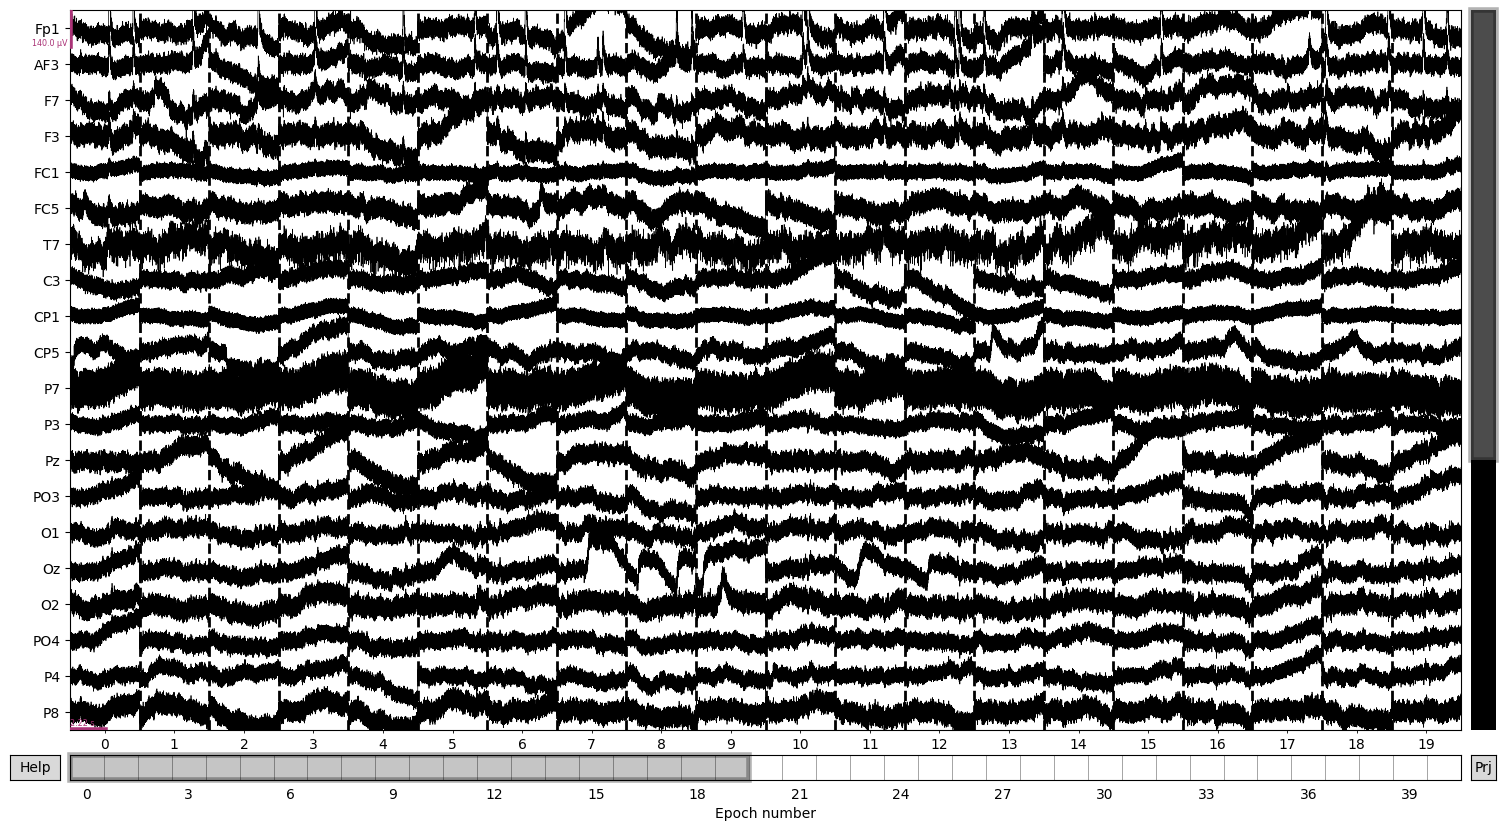

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [13]:
# Plot of epochs
%matplotlib tk
mne.viz.plot_epochs(re_ref_epochs, scalings=0.00007)

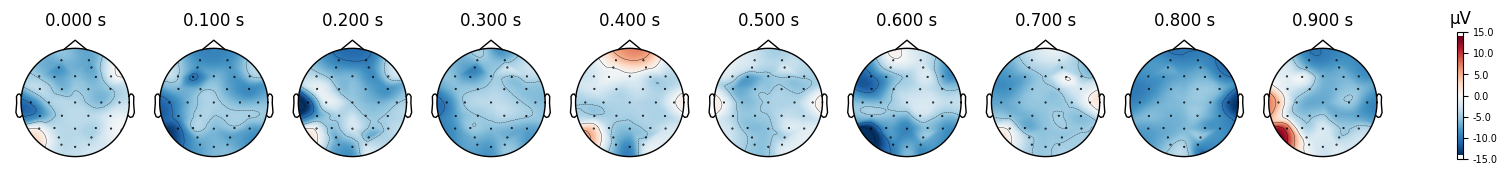

In [14]:
times = np.arange(0.0, 1.0, 0.1)
re_ref_epochs.average().plot_topomap(times, ch_type='eeg')

In [15]:
re_ref_epochs.save('epoch_data/'+participant_prefix+'.fif', verbose='error')